# Python IMAP-SMTP Client on Docker

View as [**Jupyter Notebook**](https://github.com/yoga1290/python-imap/blob/main/notebook.ipynb)

# Outline

- [**Dependecies**](#Dependecies)
- [**Receiving Emails (IMAP)**](#Receving/pulling-Emails-(IMAP))
    - [Inputs (CSV table + Env Variables)](#Inputs)
    - [Process](#Process-emails)
    - [Output (CSV table + files)](#Outputs)
- [**Sending Emails (SMTP)**](#Sending-Emails-(SMTP))
    - [Inputs (CSV table + Env Variables)](#Inputs-(Environment-Variables))
    - [Process](#Process)
    - [Output (CSV table)](#Output-(CSV-table))
- [Optimization for **CI/CD Pipeline** job](#Optimization-for-CI/CD-pipeline):
    - [Wrapping all into single entrypoint python file for **Docker** image](#Wrapping-all-into-entrypoint.py)
    - [Containerization](#Containerization-/-Dockerizing)
    - [Measuring Resource consumption (**Docker Stats**)](#Measuring-Resource-consumption-(Docker-Stats))
    - [Visualizing the **resource consumption**](#Visualizing-the-resource-consumption)
    - [Push to (Github) Container Register](#Container-Registery)
- [**Run on Docker**](#Run-on-Docker)

# Dependecies
First, let's verify the python dependecies are installed; which they should be if you're running from the pre-built Docker image.
Otherwise, they'll be installed.

In [1]:
!pip list | grep -e pandas
!python --version
# !pip install --upgrade -r requirements.txt

pandas                    3.0.1


Python 3.13.12


# Receving/pulling Emails (IMAP)

## Inputs

A good practice is to read inputs that are coming from Envirnoment Variables.
This will help passing down configurations from (Docker) Containers and/or Kubernetes to my actual running code.

Here are the **Environment Variables** needed:
- **`USERNAME`** : the username credential for the email/IMAP server
- **`APP_PASSWORD`** : the password credential for the email/IMAP server. Note, a good practice is to use App Password (generated password per "App"; Google/GMail provides such feature)
- **`N_COUNT`**: The number of most recent emails to process.
- **`IMAP_SERVER`** : the IMAP host server. (defaults to GMail's `imap.gmail.com`)
- **`IMAP_PORT`** : the IMAP port server. (defaults to GMail's `25`)
- **`FROM_EMAIL`** : Email filter; process only email `from` certain email address. (example: `<your.username>+<my-filter-name>@gmail.com`)
- **`OUTPUT_DIR`** : directory where the output CSV file and email outputs will be stored.

## Process emails

In [2]:
!source .env # update env vars; if needed
from utils import processInbox
import os

processInbox(
    USERNAME= os.getenv('USERNAME', 'USERNAME-REQUIRED@gmail.com'),
    APP_PASSWORD= os.getenv('APP_PASSWORD', 'APP-PASSWORD'),
    IMAP_SERVER= os.getenv('IMAP_SERVER', 'imap.gmail.com'),
    IMAP_PORT= int(os.getenv('IMAP_PORT', '25')),

    N_COUNT= int(os.getenv('N_COUNT', '1')),

    FROM_EMAIL=os.getenv('FROM_EMAIL', None), # example: '<username>+<filter>@gmail.com'
    TO_EMAIL=os.getenv('TO_EMAIL', None), # example: '<username>+<filter>@gmail.com'
    OUTPUT_DIR=os.getenv('OUTPUT_DIR', './data')
)

## Outputs

My `connect_imap` method returns a dict object where it can be used to create a Pandas' DataFrame, which can be easily saved as CSV file.
The dict objects has the following keys, which will be the same column names for the CSV file:

- `date`: date of the received email.
- `subject`: subject of the received email
- `files`: The file paths for the stored content and attachments of the received email. One CSV row per one file path.

In [3]:
import pandas as pd

OUTPUT_DIR=os.getenv('OUTPUT_DIR', './data')
outboxDF = pd.read_csv(f'{OUTPUT_DIR}/output.csv')
outboxDF.head(5)

,Unnamed: 0,msgId,date,from,subject,attachments
0,0,<CAH9NQxMLmqwJTnFzG88=Rv50XMtJV1oWmodJ=Gx-3O03...,"Fri, 27 Mar 2026 18:10:12 -0700",Youssef Shehab <youssef.shehab03@gmail.com>,Test RAG Document,./data/attachments/Test_RAG_Document/Fri_27_Ma...
1,1,<CAH9NQxMLmqwJTnFzG88=Rv50XMtJV1oWmodJ=Gx-3O03...,"Fri, 27 Mar 2026 18:10:12 -0700",Youssef Shehab <youssef.shehab03@gmail.com>,Test RAG Document,./data/attachments/Test_RAG_Document/Fri_27_Ma...
2,2,<CAH9NQxMsR--Eqap=zc3u9+hLXgoavnOC5f_+YnnnzCo3...,"Tue, 14 Apr 2026 12:20:10 -0400",Youssef Shehab <youssef.shehab03@gmail.com>,Test RAG doc,./data/attachments/Test_RAG_doc/Tue_14_Apr_202...
3,3,<CAH9NQxMsR--Eqap=zc3u9+hLXgoavnOC5f_+YnnnzCo3...,"Tue, 14 Apr 2026 12:20:10 -0400",Youssef Shehab <youssef.shehab03@gmail.com>,Test RAG doc,./data/attachments/Test_RAG_doc/Tue_14_Apr_202...


# Sending Emails (SMTP)

## Inputs (Environment Variables)

In [4]:
import os

USERNAME= os.getenv('USERNAME', 'USERNAME-REQUIRED@gmail.com')
APP_PASSWORD= os.getenv('APP_PASSWORD', 'APP-PASSWORD')
SMTP_SERVER= os.getenv('SMTP_SERVER', 'smtp.google.com')
SMTP_PORT=int(os.getenv('SMTP_PORT', '587'))

OUTBOX_CSV_PATH=os.getenv('OUTBOX_CSV_PATH', './data/outbox.csv')
OUTBOX_CSV_FILE_COLUMN=os.getenv('OUTBOX_CSV_FILE_COLUMN', 'BodyFilepath')
OUTBOX_CSV_EMAIL_COLUMN=os.getenv('OUTBOX_CSV_EMAIL_COLUMN', 'Email')
OUTBOX_CSV_SUBJECT_COLUMN=os.getenv('OUTBOX_CSV_SUBJECT_COLUMN', 'Subject')

### Sample CSV table

In [5]:
import pandas as pd

OUTBOX_CSV_PATH=os.getenv('OUTBOX_CSV_PATH', None)
outboxDF = pd.read_csv(OUTBOX_CSV_PATH)
outboxDF.head(5)

,Unnamed: 0,Email,Subject,BodyFilepath,Status
0,0,yoga1290@gmail.com,Test IMAP,./data/outbox.txt,OK


## Process

In [6]:
!source .env # update env vars; if needed
from utils import processOutbox
import os

processOutbox(
    USERNAME= os.getenv('USERNAME', 'USERNAME-REQUIRED@gmail.com'),
    APP_PASSWORD= os.getenv('APP_PASSWORD', 'APP-PASSWORD'),
    SMTP_SERVER= os.getenv('SMTP_SERVER', 'smtp.gmail.com'),
    SMTP_PORT= int(os.getenv('SMTP_PORT', '465')),
    
    OUTBOX_CSV_PATH=os.getenv('OUTBOX_CSV_PATH', None),
    OUTBOX_CSV_FILE_COLUMN=os.getenv('OUTBOX_CSV_FILE_COLUMN', None),
    OUTBOX_CSV_EMAIL_COLUMN=os.getenv('OUTBOX_CSV_EMAIL_COLUMN', None),
    OUTBOX_CSV_SUBJECT_COLUMN=os.getenv('OUTBOX_CSV_SUBJECT_COLUMN', None)
)

## Output (CSV table)

In [7]:
import pandas as pd

OUTBOX_CSV_PATH=os.getenv('OUTBOX_CSV_PATH', None)

outboxDF = pd.read_csv(OUTBOX_CSV_PATH)
outboxDF.head(5)

,Unnamed: 0,Email,Subject,BodyFilepath,Status
0,0,yoga1290@gmail.com,Test IMAP,./data/outbox.txt,OK


# Optimization for CI/CD pipeline

## Wrapping all into `entrypoint.py`

First I had to wrap the above code snippet to a python file which will be the entrypoint in the Dockerfile.
Let's give it a test run first:

## Containerization / Dockerizing

Now it's time to wrap it all into a Docker image.
I've wrapped the above code into `entrypoint.py`, sealed it among the dependencies required into the Docker file (`ci/docker-python/Dockerfile`) so it can be triggered locally through the Docker Compose, as well as Github Actions (CI/CD pipeline).
Now that I do not need the big Docker image for Jupyter notebook, I'm using the more optimized image for Python: `python:3.13-alpine`
I usually keep `.env` files and use `source .env` to switch the initialization of the Environment Variables between them, based on environment (dev/prod/etc).
This way, the Env Variables listed in `docker-compose.yml` are decoupled (yet documented).

## Measuring Resource consumption (Docker Stats)

Now that I have used an optimized image (`python:3.13-alpine`), let's run it in the named container `python-on-docker`, let's run this notebook on a seperate docker container `notebook-on-docker` and let a Side-Car container, the `docker-stats-monitor` measure the Memory and CPU consumption.

```shell
$> docker compose up \
            docker-stats-monitor \
            python-on-docker \
            notebook-on-docker
```

```yaml
# docker-compose.yml
services:
    docker-stats-monitor:
        image: docker:27-cli
        container_name: docker-stats-monitor
        volumes:
        - ./:/usr/app/
        - /var/run/docker.sock:/var/run/docker.sock
        entrypoint: ["watch", "-n", "5", "/bin/sh", "/usr/app/docker-stats-monitor.sh"]

    python-on-docker:
        # python:3.13-alpine + dependencies
        container_name: python-on-docker
        build:
          context: ./
          dockerfile: ./ci/docker-python/Dockerfile
        env_file:
        - .env
        volumes:
        - ./:/usr/app
    
    notebook-on-docker:
        # quay.io/jupyter/base-notebook:ubuntu-24.04 + dependencies
        container_name: notebook-on-docker
        build:
            context: ./
            dockerfile: ./ci/docker-jupyter/Dockerfile
        env_file:
        - .env
        command: bash -c 
            "jupyter execute notebook.ipynb --allow-errors --inplace 
                && jupyter nbconvert --to html notebook.ipynb"
        volumes:
        - ./:/home/jovyan
```

I used a Shell script file to trigger `docker stats` command every 5 seconds to log the resource consumption into a file.
Fyi, I can across the following tutorial/post on Docker stats command [**How to Get Docker Container Statistics in JSON Format**](https://oneuptime.com/blog/post/2026-02-08-how-to-get-docker-container-statistics-in-json-format/view). which might be useful if you want to try different tricks.

Let's have a sneakpeak on what's being logged in `docker-stats-monitor.log`:

In [8]:
!head -n 1 docker-stats-monitor.log

{"timestamp":"1774140047", "name":"notebook-on-docker","cpu":"101.00%","mem":"33.29MiB / 31.02GiB", "net":"2.17kB / 126B"}


In [9]:
import json
import pandas as pd

with open('docker-stats-monitor.log', 'r') as file:
    data = f'[ {','.join( file.readlines())} ]'
    data = json.loads(data)
    
monitorDF = pd.DataFrame(data)
monitorDF.head(5)

,timestamp,name,cpu,mem,net
0,1774140047,notebook-on-docker,101.00%,33.29MiB / 31.02GiB,2.17kB / 126B
1,1774140047,email_reader-monitor-1,0.00%,6.672MiB / 31.02GiB,564B / 84B
2,1774140055,notebook-on-docker,56.90%,190.9MiB / 31.02GiB,21.5kB / 8.17kB
3,1774140055,email_reader-monitor-1,0.08%,7.02MiB / 31.02GiB,3.3kB / 126B
4,1774140062,notebook-on-docker,93.02%,79.96MiB / 31.02GiB,36.2kB / 16.5kB


Now I drop the `%` and the units `MiB` to convert strings to float values.

Let's filter by the containers of interest for a better visubility:

In [10]:
COL_CPU_PERC='cpu'
COL_MEM='mem'
COL_CONTAINER_NAME='name'
COL_TIMESTAMP='timestamp'

COL_MEMORY='mem_float'
COL_CPU='cpu_float'

PYTHON_CONTAINER_NAME='python-on-docker'
NOTEBOOK_CONTAINER_NAME='notebook-on-docker'
# this notebook but in the headless execution mode.


filter_by_containers = (monitorDF[COL_CONTAINER_NAME]==PYTHON_CONTAINER_NAME) | (monitorDF[COL_CONTAINER_NAME]==NOTEBOOK_CONTAINER_NAME)
monitorDF = monitorDF[filter_by_containers]

monitorDF[COL_CPU] = monitorDF[COL_CPU_PERC].apply(lambda x: float(x[0:-1]))
monitorDF[COL_MEMORY] = monitorDF[COL_MEM].apply(lambda x: float(x.split('/')[0][0:-4]))
monitorDF[COL_TIMESTAMP] = monitorDF[COL_TIMESTAMP].apply(lambda x: int(x))

monitorDF.head(10)

,timestamp,name,cpu,mem,net,cpu_float,mem_float
0,1774140047,notebook-on-docker,101.00%,33.29MiB / 31.02GiB,2.17kB / 126B,101.00,33.29
2,1774140055,notebook-on-docker,56.90%,190.9MiB / 31.02GiB,21.5kB / 8.17kB,56.90,190.90
4,1774140062,notebook-on-docker,93.02%,79.96MiB / 31.02GiB,36.2kB / 16.5kB,93.02,79.96
12,1774141554,python-on-docker,0.48%,44.82MiB / 31.02GiB,77.5kB / 4.05kB,0.48,44.82
15,1774141562,python-on-docker,0.74%,45.8MiB / 31.02GiB,644kB / 29.9kB,0.74,45.80


# Resource consumption

Note, I didn't include this `matplotlib` in Docker image as visualization is here just for demonstration.

In [11]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)


  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)


  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)


  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [12]:
import matplotlib.pyplot as plt

def plot_monitor_data(monitorDF, container_name):

    df = monitorDF[monitorDF[COL_CONTAINER_NAME]==container_name]
    
    plt.subplot(1, 2, 1)
    plt.title('RAM')
    plt.plot(df[COL_TIMESTAMP], df[COL_MEMORY], color='b')
    
    plt.subplot(1, 2, 2)
    plt.title('CPU')
    plt.plot(df[COL_TIMESTAMP], df[COL_CPU], color='r')
    return plt

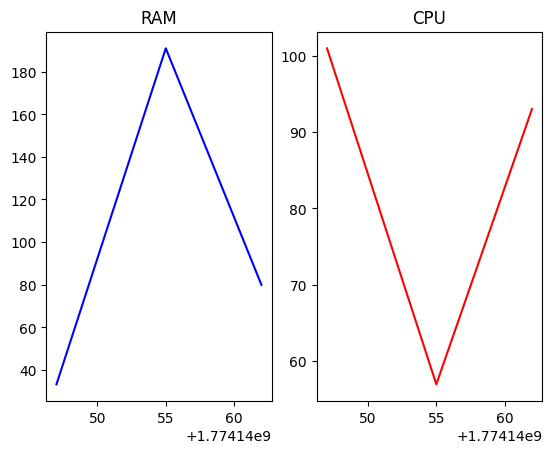

In [13]:
plot_monitor_data(monitorDF, NOTEBOOK_CONTAINER_NAME).show()

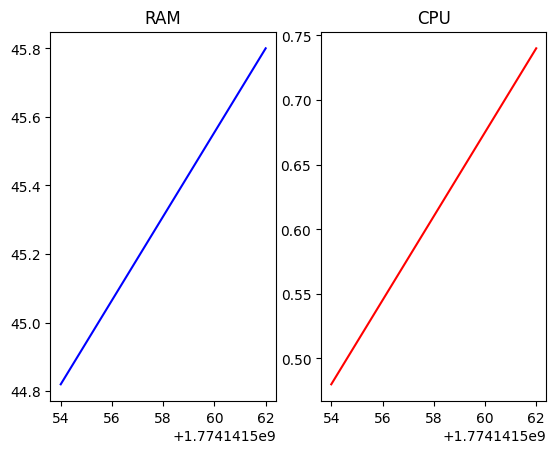

In [14]:
plot_monitor_data(monitorDF, PYTHON_CONTAINER_NAME).show()

# Container Registery

Now that the `python-on-docker` out performs the `notebook-on-docker` (actually other languages may do better; maybe Java or so), I have used the **Docker-In-Docker** docker image to run seperate Docker container with a shell script that builds, tags the Docker image and pushs it to Github Container Registry (`ghcr.io`)

```yaml
# docker-compose.yml
services:
    build-and-push-docker-image:
        image: docker:29-dind
        environment:
          GITHUB_REPOSITORY_OWNER: yoga1290
          GIT_REPOSITORY_NAME: python-imap
          DOCKER_FILE: ./ci/docker-python/Dockerfile
          ACCESS_TOKEN: ${GITHUB_TOKEN}
        command: /bin/sh +x ./ci/publish-docker-image-to-container-registry/publish-docker-image-to-container-registry.sh
        working_dir: /usr/app
        volumes:
          - ./:/usr/app
          - /var/run/docker.sock:/var/run/docker.sock
```

```shell
$> docker compose up build-and-push-docker-image
```

# Run on Docker

Now that I have pushed it to Github Container Registry, you can simply just run using the following Docker command:

```shell
$> docker run --name python-imap \
      --env-file ./env \
      -v $(pwd)/data:/usr/app/data \
      ghcr.io/yoga1290/python-imap-smtp:26.04
```